# Load Linearization Data

This notebook demonstrates how to load the linearization data (Jacobian, Variational Parameters, Prior Parameters) saved during BNN testing.

In [2]:
import torch
import os
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def load_data(run_dir, epoch):
    """
    Loads the linearization data from a specific run and epoch.
    
    Args:
        run_dir (str): Path to the Hydra output directory (e.g., 'outputs/2025-11-28/10-07-58')
        epoch (int): Epoch number to load.
        
    Returns:
        dict: The loaded data dictionary.
    """
    filepath = os.path.join(run_dir, "linearization_data", f"jacobian_epoch_{epoch}.pt")
    
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
        
    data = torch.load(filepath, map_location='cpu')
    return data

In [8]:
# Example usage
# Replace with your actual run directory
run_dir = "outputs/2025-11-29/14-58-11" 
epoch = 30_000

data = load_data(run_dir, epoch)

if data:
    print("Keys:", data.keys())
    print("Jacobian shape:", data['jacobian'].shape)
    print("Mean params shape:", data['mean_params'].shape)
    print("Prior Mean params shape:", data.get('prior_mean_params', 'Not Found').shape)
    print("Prior Var params shape:", data.get('prior_var_params', 'Not Found').shape)
    print("Inputs shape:", data['inputs'].shape)
    print("Label:", data['label'])

Keys: dict_keys(['jacobian', 'mean_params', 'inputs', 'epoch', 'label', 'model_state_dict'])
Jacobian shape: torch.Size([64, 33537])
Mean params shape: torch.Size([33537])


AttributeError: 'str' object has no attribute 'shape'

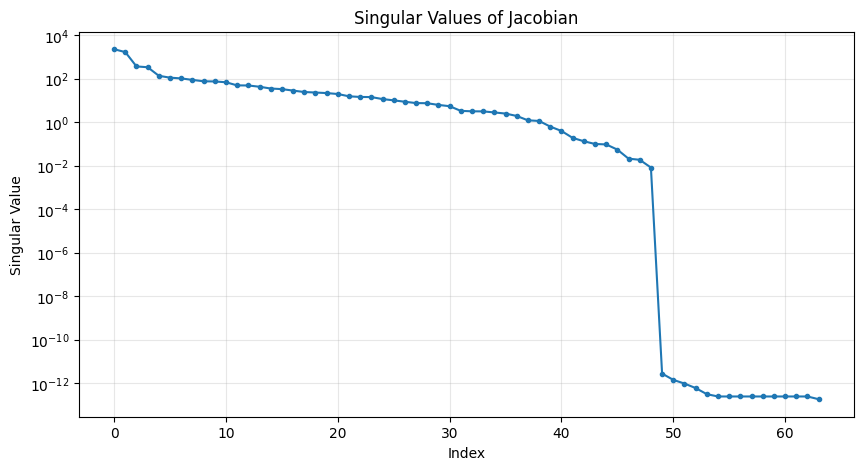

In [13]:
# Visualize Jacobian singular values
if data:
    J = data['jacobian']
    U, S, V = torch.svd(J)
    
    plt.figure(figsize=(10, 5))
    plt.plot(S.numpy(), 'o-', markersize=3)
    plt.yscale('log')
    plt.title("Singular Values of Jacobian")
    plt.xlabel("Index")
    plt.ylabel("Singular Value")
    plt.grid(True, alpha=0.3)
    plt.show()

In [14]:
print(data['jacobian'].shape)

torch.Size([64, 33537])
